# Treatment Escalation Following Metformin Initiation in Type 2 Diabetes
## A Descriptive Observational Study Using OMOP CDM Data

**Research Question:** Among adults with T2DM initiating metformin monotherapy, what demographic and clinical characteristics are associated with the *timing* of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of new metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription.

**Analytic Layers:**
1. **Descriptive Analysis** — Cohort characteristics, escalation rates, top agents
2. **Survival Analysis** — Kaplan-Meier curves and Cox proportional hazards regression
3. **Stratified Analyses** — By gender, race, ethnicity, age group, CHD, CKD, depression, hypertension
4. **Treatment Pathway Analysis** — Common sequences of therapy following metformin

**Team:** Giselle Feng (fg2618) and Nikhil Anand (na3213)

## 0. Setup and Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1. Data Loading and Cleaning

The raw data is at the **drug-exposure level**: each row represents one second-line drug exposure for a patient. A single patient may have multiple rows if they received multiple second-line agents over time.

The cleaning function below:
- Parses dates and standardizes categorical variables
- Standardizes drug names to lowercase for consistency
- Computes derived time variables (time to first escalation, follow-up duration)
- Collapses the data to **one row per patient** using the *first* second-line initiation event
- Creates age group bins for stratified analysis
- Computes censor date as min(cohort_start_date + 270 days, observation_period_end_date)

In [45]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw   — cleaned full dataset (all drug exposures, for pathway analysis)
      2. df       — one row per patient (first escalation event, for survival analysis)
    """

    # --- Load ---
    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        "cohort_start_date",
        "cohort_end_date",
        "observation_period_start_date",
        "observation_period_end_date",
        "second_line_start_date",
        "second_line_end_date",
        "censor_date",
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors="coerce")

    # --- Standardize drug names to lowercase ---
    raw["second_line_drug_name"] = raw["second_line_drug_name"].str.strip().str.lower()

    # --- Standardize categorical variables ---
    raw["gender"] = raw["gender"].str.strip().str.upper()
    raw["race"] = raw["race"].str.strip()
    raw["ethnicity"] = raw["ethnicity"].str.strip()

    # --- Compute time from metformin start to each second-line exposure (days) ---
    raw["days_to_drug"] = (
        raw["second_line_start_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Flag and report anomalies ---
    neg_time = raw[raw["days_to_drug"] < 0]
    if len(neg_time) > 0:
        print(
            f"WARNING: {len(neg_time)} exposures with negative time-to-drug (second-line before metformin). Removing."
        )
        raw = raw[raw["days_to_drug"] >= 0].copy()

    same_day = raw[raw["days_to_drug"] == 0]
    if len(same_day) > 0:
        print(
            f"NOTE: {len(same_day)} exposures on the same day as metformin initiation (day 0)."
        )

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(["person_id", "second_line_start_date"])
    df = raw.groupby("person_id").first().reset_index()

    # --- Compute censor date: min(cohort_start + 270 days, obs_period_end) ---
    df["computed_censor"] = df[["cohort_start_date"]].apply(
        lambda row: row["cohort_start_date"] + pd.Timedelta(days=270), axis=1
    )
    df["censor_date_final"] = df[
        ["computed_censor", "observation_period_end_date"]
    ].min(axis=1)

    # --- Time to first escalation (days) ---
    df["time_to_escalation"] = (
        df["second_line_start_date"] - df["cohort_start_date"]
    ).dt.days

    # --- Event indicator: all patients escalated (no censoring in this dataset) ---
    df["event"] = 1

    # --- Age groups ---
    df["age_group"] = pd.cut(
        df["age_at_index"],
        bins=[17, 44, 64, 74, 120],
        labels=["18-44", "45-64", "65-74", "75+"],
    )

    # --- Follow-up duration ---
    df["followup_days"] = (df["censor_date_final"] - df["cohort_start_date"]).dt.days

    # --- Rename flag columns for clarity ---
    df = df.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )
    df_raw = df_raw.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )

    # --- Report ---
    print(f"\nCleaned patient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(
        f"  Range: {df['time_to_escalation'].min()} - {df['time_to_escalation'].max()} days"
    )
    print(f"  Mean follow-up window: {df['followup_days'].mean():.0f} days")

    return df_raw, df


df_raw, df = clean_and_prepare("../Data/cohort_raw.csv")

Raw data: 25182 rows, 9951 unique patients
NOTE: 1867 exposures on the same day as metformin initiation (day 0).

Cleaned patient-level data: 9951 patients
  Median time to escalation: 81 days
  Range: 0 - 690 days
  Mean follow-up window: 268 days


---
## Layer 1: Descriptive Analysis

### 1.1 Table 1 — Baseline Characteristics

Standard summary of cohort demographics and comorbidities, reported as counts and percentages for categorical variables, and median (IQR) for continuous variables.

In [46]:
def make_table1(df):
    """Generate a Table 1 of baseline characteristics."""

    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean)", f"{med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table1 = make_table1(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table1.to_string(index=False))

TABLE 1: Baseline Characteristics
                         Characteristic       Value       
              Median Age at Index (IQR)  74 (67–82)       
Time to escalation (days), median (IQR) 81 (14–192)       
                                                          
                             **Gender**           n      %
                                 FEMALE        6153  61.8%
                                   MALE        3798  38.2%
                               **Race**           n      %
              Black or African American        1210  12.2%
                                  White        8741  87.8%
                          **Ethnicity**           n      %
                 Not Hispanic or Latino        9951 100.0%
                          **Age group**           n      %
                                  18-44         448   4.5%
                                  45-64        1490  15.0%
                                  65-74        3250  32.7%
                      

### 1.2 Top Second-Line Agents

Distribution of the first second-line antidiabetic agent initiated after metformin.

First second-line agent initiated after metformin:
---------------------------------------------
  glyburide             n=4083  (41.0%)
  glipizide             n=2699  (27.1%)
  rosiglitazone         n=1107  (11.1%)
  glimepiride           n=788  (7.9%)
  pioglitazone          n=728  (7.3%)
  sitagliptin           n=289  (2.9%)
  repaglinide           n=141  (1.4%)
  nateglinide           n= 77  (0.8%)
  insulin glargine      n= 26  (0.3%)
  insulin detemir       n=  9  (0.1%)
  saxagliptin           n=  4  (0.0%)
                      N=9951


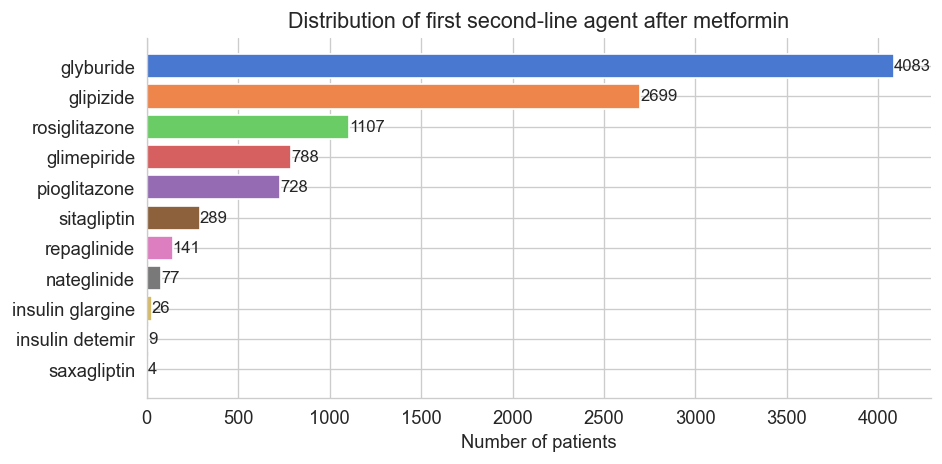

In [47]:
# Top second-line agents (first agent per patient)
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"  {drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 1.3 Distribution of Time to Escalation

Histogram and descriptive statistics for the primary outcome: days from metformin initiation to first second-line drug.

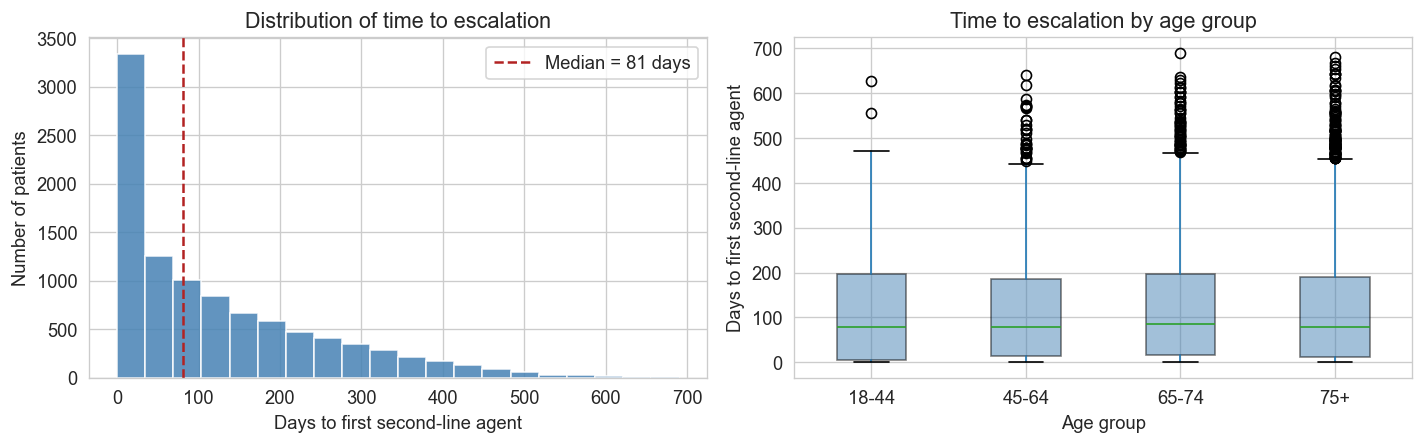


Descriptive statistics — Time to escalation (days):
count    9951.0
mean      122.0
std       128.5
min         0.0
25%        14.0
50%        81.0
75%       192.0
max       690.0
Name: time_to_escalation, dtype: float64


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(
    df["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
axes[0].axvline(
    df["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df['time_to_escalation'].median():.0f} days",
)
axes[0].set_xlabel("Days to first second-line agent")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Distribution of time to escalation")
axes[0].legend()

# Box plot by age group
df.boxplot(
    column="time_to_escalation",
    by="age_group",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Days to first second-line agent")
axes[1].set_title("Time to escalation by age group")
plt.suptitle("")  # remove automatic pandas suptitle

plt.tight_layout()
plt.show()

# Summary stats
print("\nDescriptive statistics — Time to escalation (days):")
print(df["time_to_escalation"].describe().round(1))

### 1.4 Comorbidity Co-occurrence

Cross-tabulation of baseline comorbidities to understand burden and co-occurrence patterns.

Comorbidity count distribution:
comorbidity_count
0     924
1    2173
2    3373
3    3051
4     430
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           952         602   874   648
depression             602        5066  4660  3302
chd                    874        4660  8314  5020
ckd                    648        3302  5020  5460


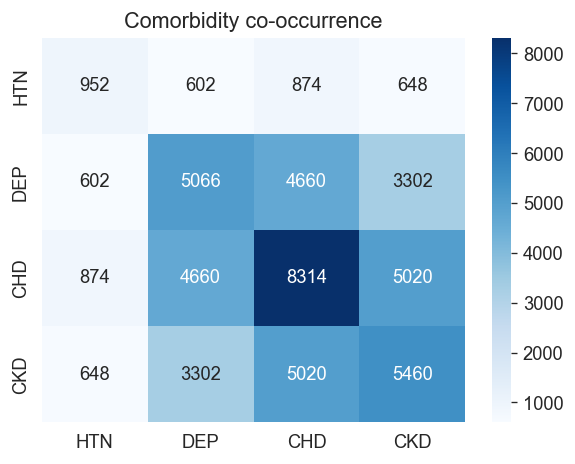

In [49]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["HTN", "DEP", "CHD", "CKD"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity co-occurrence")
plt.tight_layout()
plt.show()

### 1.5 Time to Escalation by Comorbidity Status

Comparing median escalation times across comorbidity subgroups to identify preliminary patterns before formal modeling.

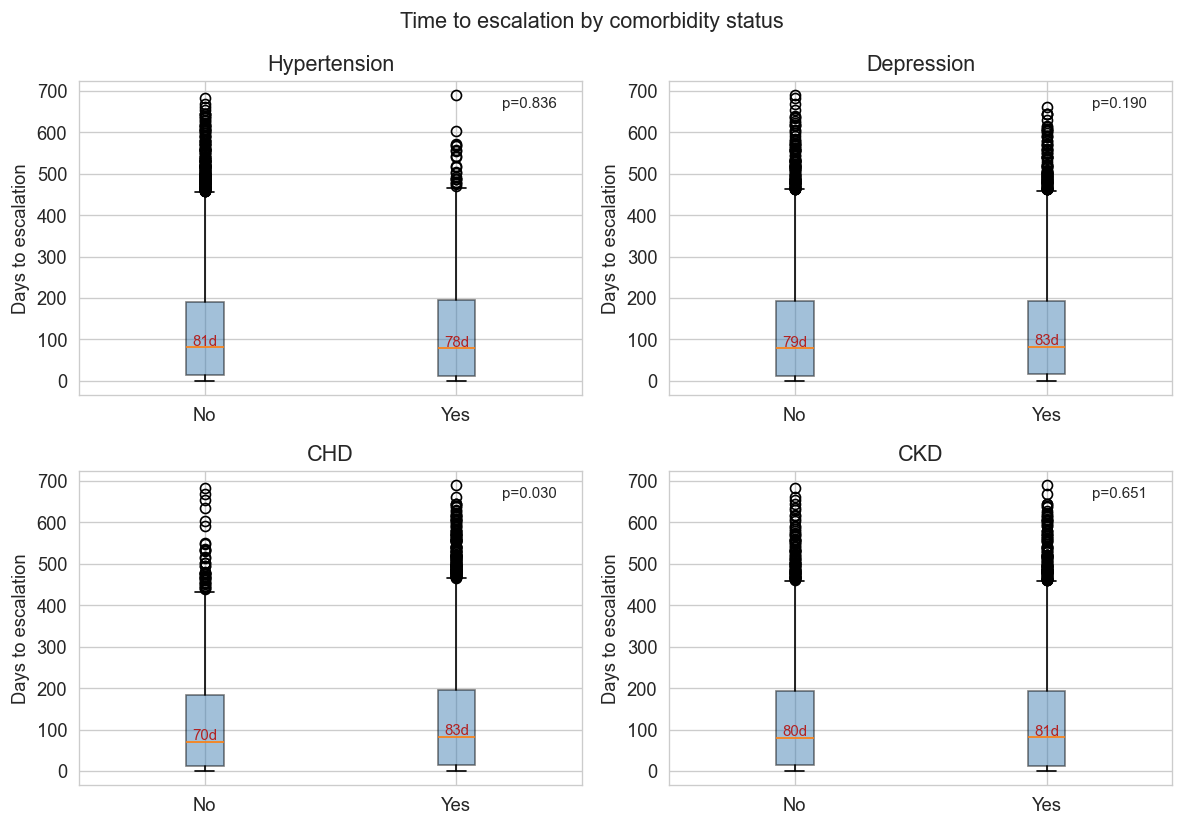

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (label, col) in zip(axes.ravel(), 
    [('Hypertension', 'hypertension'), ('Depression', 'depression'),
     ('CHD', 'chd'), ('CKD', 'ckd')]):
    
    groups = df.groupby(col)['time_to_escalation']
    medians = groups.median()
    
    data_0 = df[df[col] == 0]['time_to_escalation']
    data_1 = df[df[col] == 1]['time_to_escalation']
    
    ax.boxplot([data_0, data_1], labels=['No', 'Yes'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(f'{label}')
    ax.set_ylabel('Days to escalation')
    
    # Add median labels
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(i + 1, med + 5, f'{med:.0f}d', ha='center', fontsize=9, color='firebrick')
    
    # Mann-Whitney U test
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
        ax.text(0.95, 0.95, f'p={p:.3f}', transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Time to escalation by comorbidity status', fontsize=13)
plt.tight_layout()
plt.show()

---
## Layer 2: Survival Analysis

### 2.1 Overall Kaplan-Meier Curve

Since all patients in this dataset were escalated (event = 1 for all), the KM curve shows the cumulative proportion who have been escalated over time. There are no censored observations.

**Limitation:** This dataset includes only patients who *were* escalated. Patients who remained on metformin monotherapy throughout the observation period are excluded. The KM curve therefore represents the distribution of escalation timing conditional on escalation occurring, not the overall probability of escalation in the full cohort.

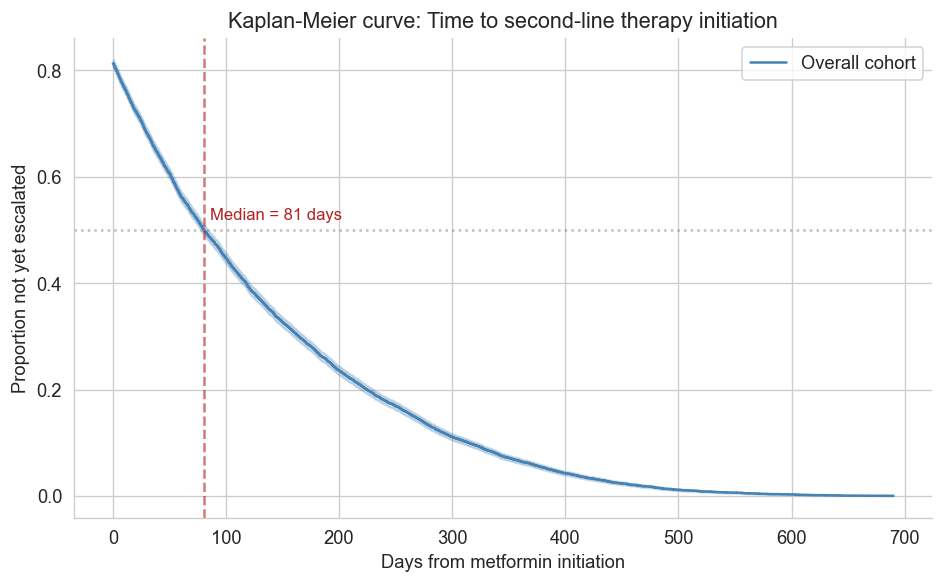

Median time to escalation: 81 days
Mean time to escalation: 122.0 days


In [ ]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(8, 5))

kmf.fit(df["time_to_escalation"], event_observed=df["event"], label="Overall cohort")
kmf.plot_survival_function(ax=ax, ci_show=True, color="steelblue")

ax.set_xlabel("Days from metformin initiation")
ax.set_ylabel("Proportion not yet escalated")
ax.set_title("Kaplan-Meier curve: Time to second-line therapy initiation")
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)

median_surv = kmf.median_survival_time_
ax.axvline(x=median_surv, color="firebrick", linestyle="--", alpha=0.6)
ax.text(
    median_surv + 5,
    0.52,
    f"Median = {median_surv:.0f} days",
    color="firebrick",
    fontsize=10,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Median time to escalation: {median_surv:.0f} days")
print(f"Mean time to escalation: {df['time_to_escalation'].mean():.1f} days")

### 2.2 Kaplan-Meier Curves — Stratified

KM curves stratified by each demographic and clinical characteristic, with log-rank tests for group differences.

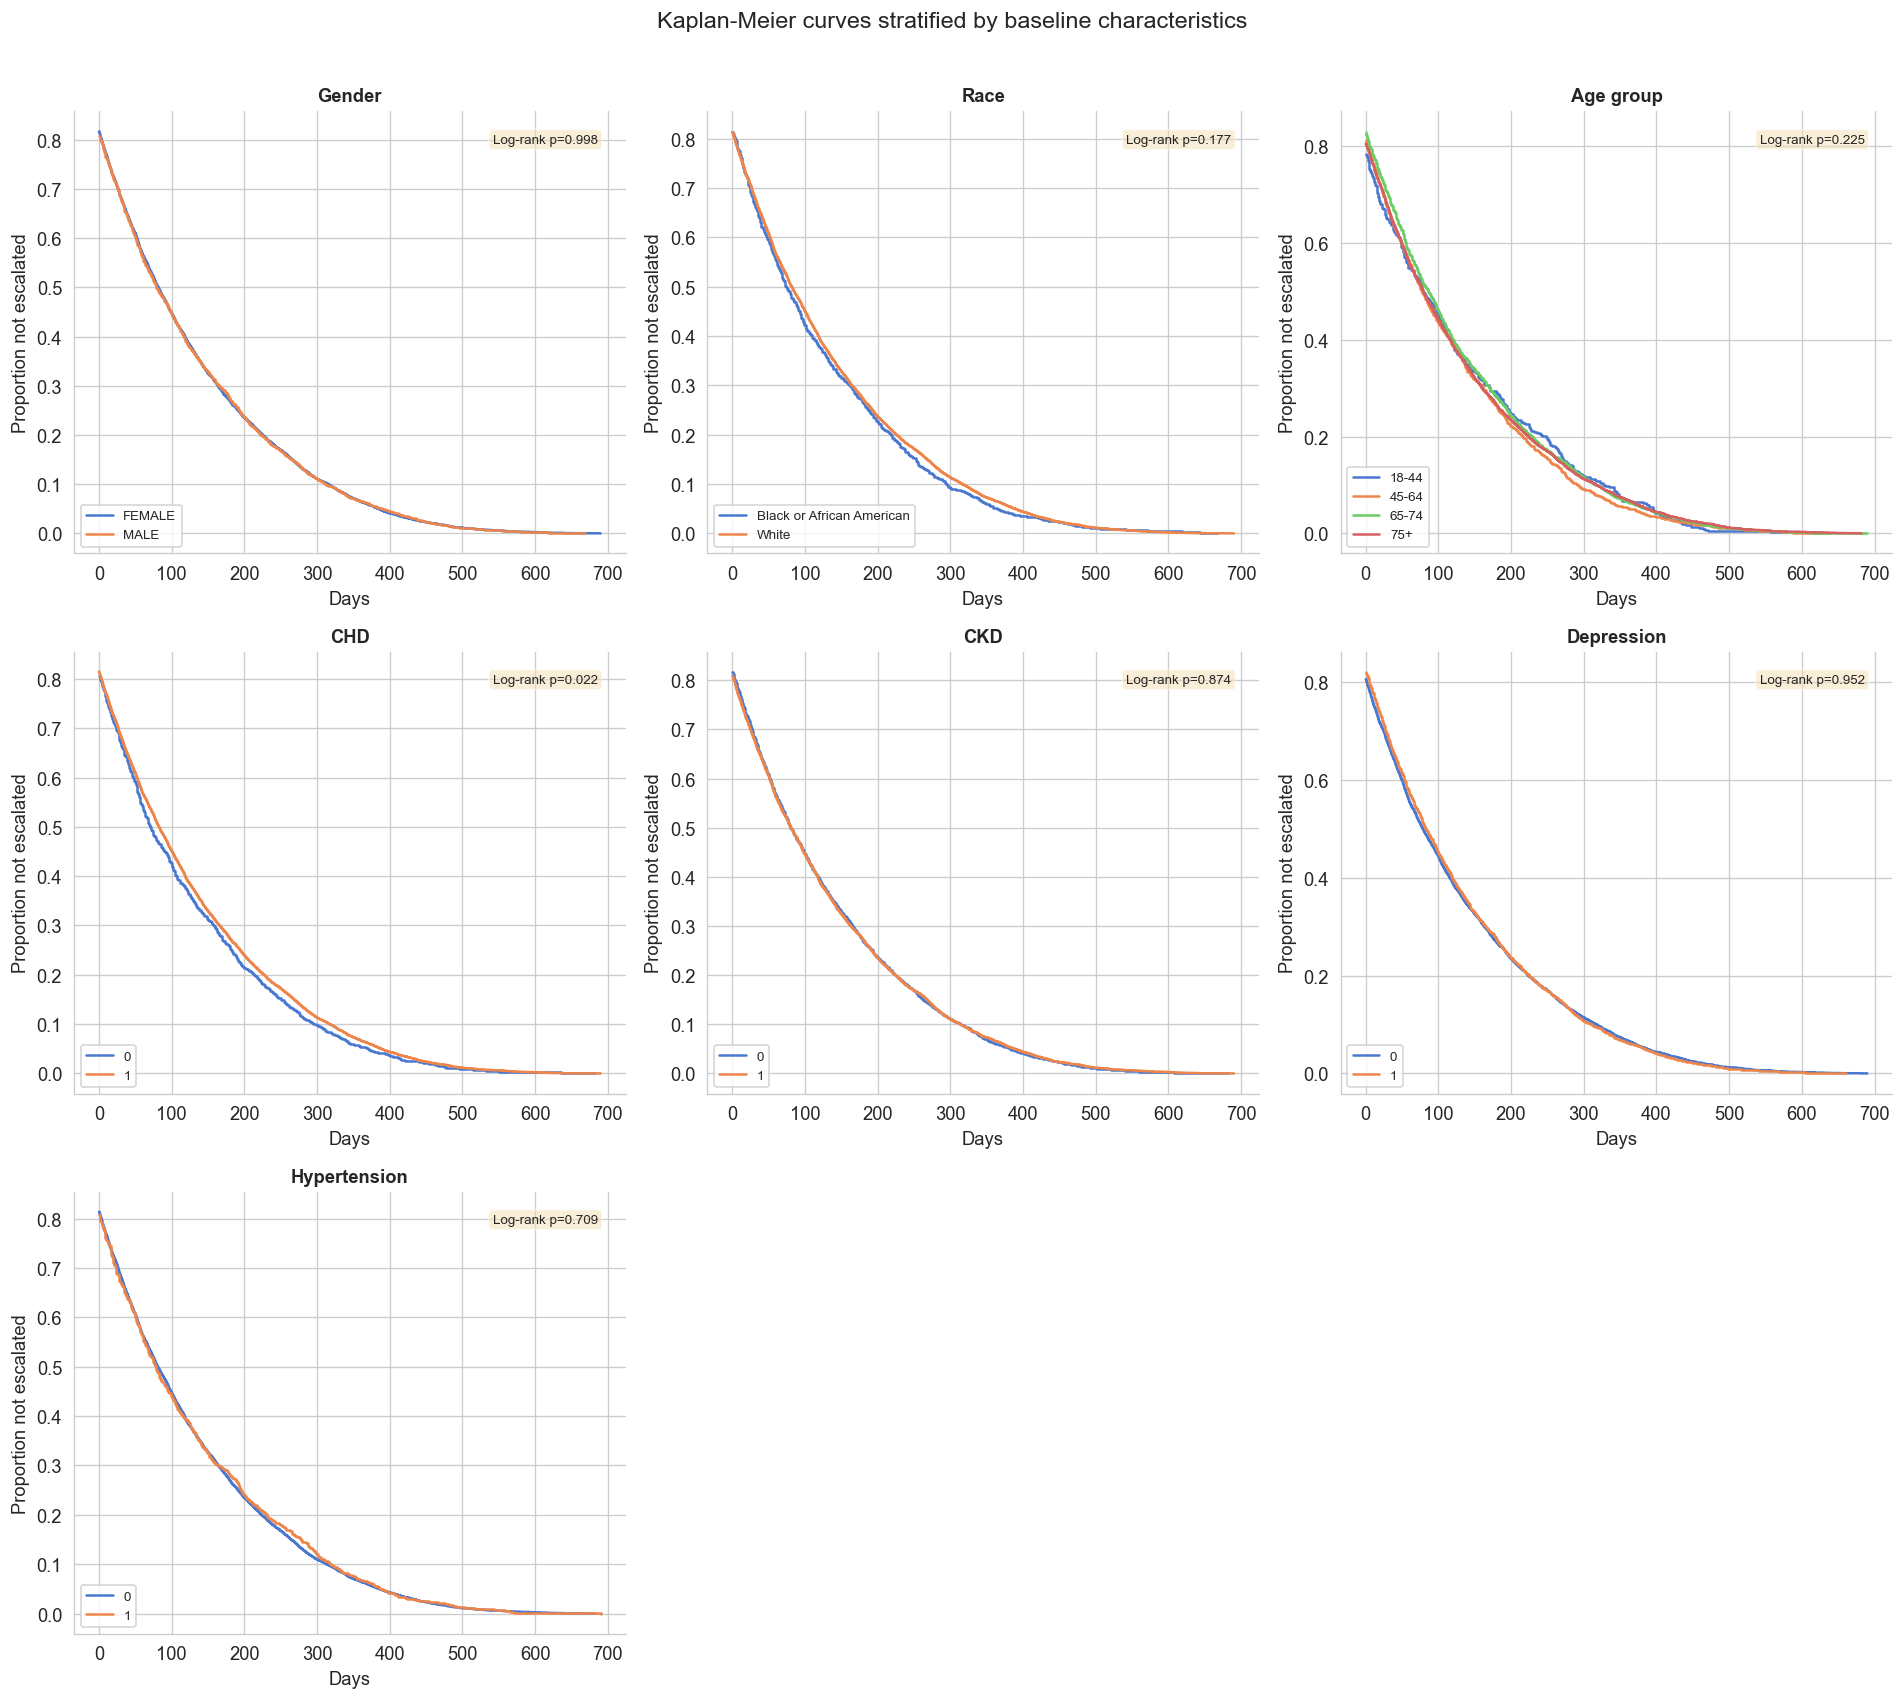

In [52]:
strat_vars = {
    'Gender': 'gender',
    'Race': 'race',
    'Age group': 'age_group',
    'CHD': 'chd',
    'CKD': 'ckd',
    'Depression': 'depression',
    'Hypertension': 'hypertension',
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

kmf = KaplanMeierFitter()

for idx, (title, col) in enumerate(strat_vars.items()):
    ax = axes[idx]
    groups = df[col].dropna().unique()
    groups = sorted(groups, key=lambda x: str(x))
    
    palette = sns.color_palette("muted", len(groups))
    
    for i, grp in enumerate(groups):
        mask = df[col] == grp
        if mask.sum() < 2:
            continue
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=str(grp))
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel('Proportion not escalated')
    ax.legend(fontsize=8, loc='lower left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Log-rank test (only if >=2 groups with >=2 observations each)
    valid_groups = [g for g in groups if (df[col] == g).sum() >= 2]
    if len(valid_groups) >= 2:
        try:
            result = multivariate_logrank_test(
                df.loc[df[col].isin(valid_groups), 'time_to_escalation'],
                df.loc[df[col].isin(valid_groups), col],
                df.loc[df[col].isin(valid_groups), 'event']
            )
            p = result.p_value
            ax.text(0.95, 0.95, f'Log-rank p={p:.3f}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
        except Exception:
            pass

# Hide unused axes
for idx in range(len(strat_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Kaplan-Meier curves stratified by baseline characteristics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Cox Proportional Hazards Model

A multivariable Cox regression to identify characteristics independently associated with the hazard (rate) of second-line therapy initiation. 

**Interpretation:** A hazard ratio > 1 means faster escalation (shorter time to second-line therapy). A hazard ratio < 1 means slower escalation.

Covariates: age (continuous), gender, race, CHD, CKD, depression, hypertension.

In [ ]:
# Prepare data for Cox regression
cox_df = df[
    [
        "time_to_escalation",
        "event",
        "age_at_index",
        "gender",
        "race",
        "chd",
        "ckd",
        "depression",
        "hypertension",
    ]
].copy()

# Encode gender: FEMALE = 0, MALE = 1
cox_df["male"] = (cox_df["gender"] == "MALE").astype(int)

# Encode race: dummies with White as reference
race_dummies = pd.get_dummies(cox_df["race"], prefix="race", drop_first=False)
# Use White as reference if present
if "race_White" in race_dummies.columns:
    race_dummies = race_dummies.drop(columns=["race_White"])
else:
    race_dummies = race_dummies.iloc[:, 1:]  # drop first alphabetically

cox_df = pd.concat([cox_df, race_dummies], axis=1)
cox_df = cox_df.drop(columns=["gender", "race"])

# Rename for readability
cox_df.columns = [c.replace("race_", "race: ") for c in cox_df.columns]

print("Cox model input shape:", cox_df.shape)
print("\nVariable summary:")
print(cox_df.describe().T[["mean", "std", "min", "max"]].round(2))

Cox model input shape: (9951, 9)

Variable summary:
                      mean     std   min    max
time_to_escalation  122.03  128.46   0.0  690.0
event                 1.00    0.00   1.0    1.0
age_at_index         72.70   13.76  26.0  100.0
chd                   0.84    0.37   0.0    1.0
ckd                   0.55    0.50   0.0    1.0
depression            0.51    0.50   0.0    1.0
hypertension          0.10    0.29   0.0    1.0
male                  0.38    0.49   0.0    1.0


In [54]:
# Fit Cox PH model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='time_to_escalation', event_col='event')

print("\n" + "=" * 70)
print("COX PROPORTIONAL HAZARDS MODEL — RESULTS")
print("=" * 70)
cph.print_summary(columns=['coef', 'exp(coef)', 'se(coef)', 'p', 'exp(coef) lower 95%', 'exp(coef) upper 95%'])


COX PROPORTIONAL HAZARDS MODEL — RESULTS


AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 9951 total observations, 0 right-censored observations>
             duration col = 'time_to_escalation'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 9951
number of events observed = 9951
   partial log-likelihood = -81654.08
         time fit was run = 2026-04-19 18:42:08 UTC

---
                                 coef exp(coef)  se(coef) exp(coef) lower 95% exp(coef) upper 95%    p
covariate                                                                                             
age_at_index                    -0.00      1.00      0.00                1.00                1.00 0.95
chd                             -0.07      0.94      0.03                0.88                0.99 0.02
ckd                              0.01      1.01      0.02                0.97                1.05 0.69
depression                       0.01      1.01      0.02                0.97                1.05 0.75
hypertension                    -0.01      0.99      0.03                0.93                1.06 0.80
male                             0.00      1.00      0.02                0.96                1.04 0.95
race: Black or African American  0.04      1.04      0.03                0.98                1.11 0.19
---
Concordance = 0.51
Partial AIC = 163322.17
log-likelihood ratio test = 7.31 on 7 df
-log2(p) of ll-ratio test = 1.33

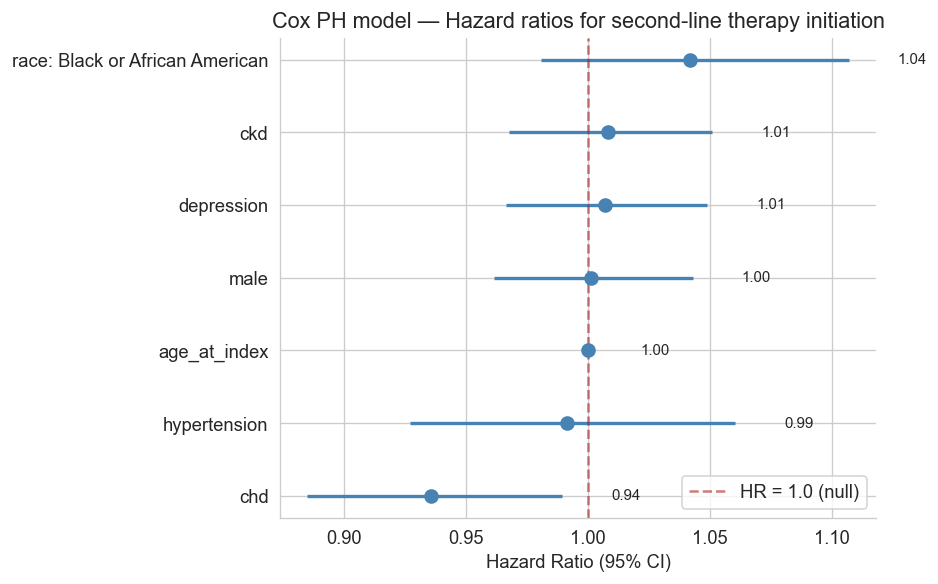

In [55]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))

summary = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].copy()
summary = summary.sort_values('exp(coef)')

y_pos = range(len(summary))
ax.hlines(y_pos, summary['exp(coef) lower 95%'], summary['exp(coef) upper 95%'],
          color='steelblue', linewidth=2)
ax.scatter(summary['exp(coef)'], y_pos, color='steelblue', s=60, zorder=3)
ax.axvline(x=1.0, color='firebrick', linestyle='--', alpha=0.6, label='HR = 1.0 (null)')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title('Cox PH model — Hazard ratios for second-line therapy initiation')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='lower right')

# Add HR labels
for i, (idx, row) in enumerate(summary.iterrows()):
    ax.text(row['exp(coef) upper 95%'] + 0.02, i,
            f"{row['exp(coef)']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Cox Model Diagnostics

Checking the proportional hazards assumption via Schoenfeld residual tests. A significant p-value (< 0.05) suggests the proportional hazards assumption may be violated for that covariate.

In [56]:
# Proportional hazards test
print("Proportional Hazards Assumption Test (Schoenfeld residuals)")
print("=" * 60)
try:
    ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"PH test result: {e}")
    print("\nNote: With a small sample (N=~50) and no censoring, these tests have")
    print("limited power. Interpret with caution.")

Proportional Hazards Assumption Test (Schoenfeld residuals)
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'depression' failed the non-proportional test: p-value is 0.0101.

   Advice: with so few unique values (only 2), you can include `strata=['depression', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



---
## Layer 3: Stratified Cox Models

Running separate Cox models within demographic and clinical subgroups to examine whether the effect of covariates on escalation timing varies across strata. 

For binary stratification variables, we compare HRs across strata; for multi-level variables (age group, race), we describe covariate effects within each stratum.

In [57]:
def run_stratified_cox(df, strat_col, strat_label, covariate_cols):
    """
    Run Cox PH model within each stratum of strat_col.
    Returns a summary DataFrame of HRs across strata.
    """
    results = []
    strata = sorted(df[strat_col].dropna().unique(), key=lambda x: str(x))
    
    for stratum in strata:
        subset = df[df[strat_col] == stratum].copy()
        if len(subset) < 10:
            print(f"  Skipping {strat_label}={stratum}: n={len(subset)} (too few)")
            continue
        
        # Select covariates that have variance in this subset
        valid_covs = []
        for c in covariate_cols:
            if c in subset.columns and subset[c].nunique() > 1:
                valid_covs.append(c)
        
        if len(valid_covs) == 0:
            print(f"  Skipping {strat_label}={stratum}: no valid covariates with variance")
            continue
        
        model_df = subset[['time_to_escalation', 'event'] + valid_covs].dropna()
        
        if len(model_df) < 10:
            continue
        
        try:
            cph_s = CoxPHFitter(penalizer=0.1)  # light regularization for small strata
            cph_s.fit(model_df, duration_col='time_to_escalation', event_col='event')
            
            for cov in valid_covs:
                hr = cph_s.hazard_ratios_[cov]
                ci_low = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[0])
                ci_high = np.exp(cph_s.confidence_intervals_.loc[cov].iloc[1])
                p = cph_s.summary.loc[cov, 'p']
                results.append({
                    'Stratum': f'{strat_label}={stratum}',
                    'N': len(model_df),
                    'Covariate': cov,
                    'HR': hr,
                    'CI_low': ci_low,
                    'CI_high': ci_high,
                    'p': p
                })
        except Exception as e:
            print(f"  {strat_label}={stratum}: model failed ({e})")
    
    return pd.DataFrame(results)


# Core covariates for stratified models
base_covs = ['age_at_index', 'male', 'chd', 'ckd', 'depression', 'hypertension']

# Prepare male variable in df if not already
df['male'] = (df['gender'] == 'MALE').astype(int)

print("=" * 70)
print("STRATIFIED COX MODELS")
print("=" * 70)

STRATIFIED COX MODELS


In [58]:
# Stratify by gender
print("\n--- Stratified by Gender ---")
gender_results = run_stratified_cox(df, 'gender', 'Gender',
    ['age_at_index', 'chd', 'ckd', 'depression', 'hypertension'])
if len(gender_results) > 0:
    print(gender_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Gender ---
      Stratum    N    Covariate    HR  CI_low  CI_high     p
Gender=FEMALE 6153 age_at_index 1.001   0.999    1.002 0.449
Gender=FEMALE 6153          chd 0.975   0.912    1.043 0.458
Gender=FEMALE 6153          ckd 1.019   0.969    1.071 0.466
Gender=FEMALE 6153   depression 1.019   0.971    1.071 0.442
Gender=FEMALE 6153 hypertension 0.965   0.890    1.047 0.393
  Gender=MALE 3798 age_at_index 0.999   0.996    1.001 0.219
  Gender=MALE 3798          chd 0.894   0.820    0.974 0.010
  Gender=MALE 3798          ckd 0.988   0.927    1.053 0.707
  Gender=MALE 3798   depression 0.985   0.925    1.049 0.642
  Gender=MALE 3798 hypertension 1.042   0.938    1.156 0.443


In [59]:
# Stratify by age group
print("\n--- Stratified by Age Group ---")
age_results = run_stratified_cox(df, 'age_group', 'Age',
    ['male', 'chd', 'ckd', 'depression', 'hypertension'])
if len(age_results) > 0:
    print(age_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Age Group ---
  Stratum    N    Covariate    HR  CI_low  CI_high     p
Age=18-44  448         male 0.987   0.826    1.179 0.882
Age=18-44  448          chd 0.908   0.705    1.171 0.457
Age=18-44  448          ckd 0.996   0.828    1.199 0.969
Age=18-44  448   depression 0.991   0.821    1.196 0.922
Age=18-44  448 hypertension 0.936   0.701    1.249 0.654
Age=45-64 1490         male 1.013   0.919    1.117 0.795
Age=45-64 1490          chd 0.853   0.743    0.980 0.025
Age=45-64 1490          ckd 1.009   0.912    1.117 0.858
Age=45-64 1490   depression 1.068   0.966    1.181 0.198
Age=45-64 1490 hypertension 0.936   0.798    1.098 0.418
Age=65-74 3250         male 1.052   0.984    1.124 0.140
Age=65-74 3250          chd 0.948   0.868    1.035 0.233
Age=65-74 3250          ckd 1.017   0.950    1.090 0.624
Age=65-74 3250   depression 1.020   0.953    1.092 0.562
Age=65-74 3250 hypertension 0.974   0.867    1.095 0.662
  Age=75+ 4763         male 0.964   0.910    1.021 0.20

In [60]:
# Stratify by CHD
print("\n--- Stratified by CHD ---")
chd_results = run_stratified_cox(df, 'chd', 'CHD',
    ['age_at_index', 'male', 'ckd', 'depression', 'hypertension'])
if len(chd_results) > 0:
    print(chd_results.to_string(index=False, float_format='%.3f'))


--- Stratified by CHD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CHD=0 1637 age_at_index 1.000   0.996    1.003 0.883
  CHD=0 1637         male 1.090   0.991    1.200 0.077
  CHD=0 1637          ckd 0.993   0.893    1.103 0.890
  CHD=0 1637   depression 0.987   0.885    1.101 0.816
  CHD=0 1637 hypertension 1.024   0.824    1.273 0.831
  CHD=1 8314 age_at_index 1.000   0.998    1.001 0.888
  CHD=1 8314         male 0.983   0.942    1.026 0.431
  CHD=1 8314          ckd 1.011   0.969    1.055 0.613
  CHD=1 8314   depression 1.010   0.969    1.053 0.643
  CHD=1 8314 hypertension 0.991   0.927    1.060 0.787


In [61]:
# Stratify by CKD
print("\n--- Stratified by CKD ---")
ckd_results = run_stratified_cox(df, 'ckd', 'CKD',
    ['age_at_index', 'male', 'chd', 'depression', 'hypertension'])
if len(ckd_results) > 0:
    print(ckd_results.to_string(index=False, float_format='%.3f'))


--- Stratified by CKD ---
Stratum    N    Covariate    HR  CI_low  CI_high     p
  CKD=0 4491 age_at_index 1.000   0.998    1.002 0.875
  CKD=0 4491         male 1.028   0.971    1.089 0.342
  CKD=0 4491          chd 0.939   0.880    1.002 0.058
  CKD=0 4491   depression 0.984   0.928    1.044 0.599
  CKD=0 4491 hypertension 0.976   0.873    1.091 0.672
  CKD=1 5460 age_at_index 1.000   0.998    1.002 0.911
  CKD=1 5460         male 0.979   0.929    1.031 0.420
  CKD=1 5460          chd 0.954   0.868    1.048 0.324
  CKD=1 5460   depression 1.022   0.970    1.077 0.406
  CKD=1 5460 hypertension 1.001   0.926    1.083 0.974


In [62]:
# Stratify by Depression
print("\n--- Stratified by Depression ---")
dep_results = run_stratified_cox(df, 'depression', 'Depression',
    ['age_at_index', 'male', 'chd', 'ckd', 'hypertension'])
if len(dep_results) > 0:
    print(dep_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Depression ---
     Stratum    N    Covariate    HR  CI_low  CI_high     p
Depression=0 4885 age_at_index 1.001   0.999    1.003 0.491
Depression=0 4885         male 1.029   0.974    1.088 0.308
Depression=0 4885          chd 0.941   0.883    1.003 0.063
Depression=0 4885          ckd 0.991   0.937    1.047 0.737
Depression=0 4885 hypertension 0.928   0.836    1.030 0.159
Depression=1 5066 age_at_index 0.999   0.997    1.001 0.339
Depression=1 5066         male 0.972   0.921    1.027 0.313
Depression=1 5066          chd 0.957   0.868    1.055 0.379
Depression=1 5066          ckd 1.026   0.970    1.085 0.366
Depression=1 5066 hypertension 1.038   0.957    1.126 0.367


In [63]:
# Stratify by Hypertension
print("\n--- Stratified by Hypertension ---")
htn_results = run_stratified_cox(df, 'hypertension', 'Hypertension',
    ['age_at_index', 'male', 'chd', 'ckd', 'depression'])
if len(htn_results) > 0:
    print(htn_results.to_string(index=False, float_format='%.3f'))


--- Stratified by Hypertension ---
       Stratum    N    Covariate    HR  CI_low  CI_high     p
Hypertension=0 8999 age_at_index 1.000   0.998    1.001 0.685
Hypertension=0 8999         male 0.995   0.955    1.036 0.796
Hypertension=0 8999          chd 0.948   0.898    1.001 0.053
Hypertension=0 8999          ckd 1.006   0.966    1.048 0.767
Hypertension=0 8999   depression 0.994   0.954    1.035 0.771
Hypertension=1  952 age_at_index 1.001   0.997    1.006 0.542
Hypertension=1  952         male 1.061   0.935    1.204 0.358
Hypertension=1  952          chd 0.889   0.707    1.119 0.316
Hypertension=1  952          ckd 1.037   0.907    1.186 0.595
Hypertension=1  952   depression 1.114   0.980    1.265 0.099


### 3.1 Median Time to Escalation — Summary Table by Subgroup

A consolidated view of median escalation times and interquartile ranges across all stratification variables.

In [64]:
def median_by_subgroup(df, col, label):
    """Compute median (IQR) time to escalation by subgroup."""
    rows = []
    for val in sorted(df[col].dropna().unique(), key=lambda x: str(x)):
        subset = df[df[col] == val]['time_to_escalation']
        rows.append({
            'Variable': label,
            'Subgroup': str(val),
            'N': len(subset),
            'Median (days)': subset.median(),
            'IQR': f"{subset.quantile(0.25):.0f}–{subset.quantile(0.75):.0f}",
            'Mean (days)': subset.mean()
        })
    return pd.DataFrame(rows)

strat_summary = pd.concat([
    median_by_subgroup(df, 'gender', 'Gender'),
    median_by_subgroup(df, 'age_group', 'Age group'),
    median_by_subgroup(df, 'race', 'Race'),
    median_by_subgroup(df, 'chd', 'CHD'),
    median_by_subgroup(df, 'ckd', 'CKD'),
    median_by_subgroup(df, 'depression', 'Depression'),
    median_by_subgroup(df, 'hypertension', 'Hypertension'),
], ignore_index=True)

print("Median time to escalation by subgroup:")
print("=" * 75)
print(strat_summary.to_string(index=False, float_format='%.1f'))

Median time to escalation by subgroup:
    Variable                  Subgroup    N  Median (days)    IQR  Mean (days)
      Gender                    FEMALE 6153           82.0 14–191        122.2
      Gender                      MALE 3798           79.0 14–193        121.8
   Age group                     18-44  448           79.0  6–197        122.4
   Age group                     45-64 1490           78.0 14–186        117.0
   Age group                     65-74 3250           86.0 17–197        125.3
   Age group                       75+ 4763           79.0 12–189        121.4
        Race Black or African American 1210           74.0 14–187        116.9
        Race                     White 8741           82.0 14–193        122.7
         CHD                         0 1637           70.0 12–183        115.1
         CHD                         1 8314           83.0 14–195        123.4
         CKD                         0 4491           80.0 15–193        122.1
         CKD 

---
## Layer 4: Treatment Pathway Analysis

Using the full drug-exposure-level dataset (all rows, not collapsed), we examine the sequences of second-line therapy following metformin initiation.

This addresses a key feedback point: moving beyond simply identifying the *first* second-line agent to describing the *trajectories* of treatment — common sequences, switching patterns, and the number of distinct agents used per patient.

### 4.1 Drug Exposure Counts and Sequencing

For each patient, we reconstruct the ordered sequence of second-line drugs received after metformin initiation.

Exposures per patient:
count    9951.0
mean        2.5
std         1.8
min         1.0
25%         1.0
50%         2.0
75%         3.0
max        18.0
Name: n_exposures, dtype: float64

Distinct second-line drugs per patient:
n_distinct_drugs
1    4533
2    3116
3    1564
4     589
5     127
6      18
7       4
Name: count, dtype: int64


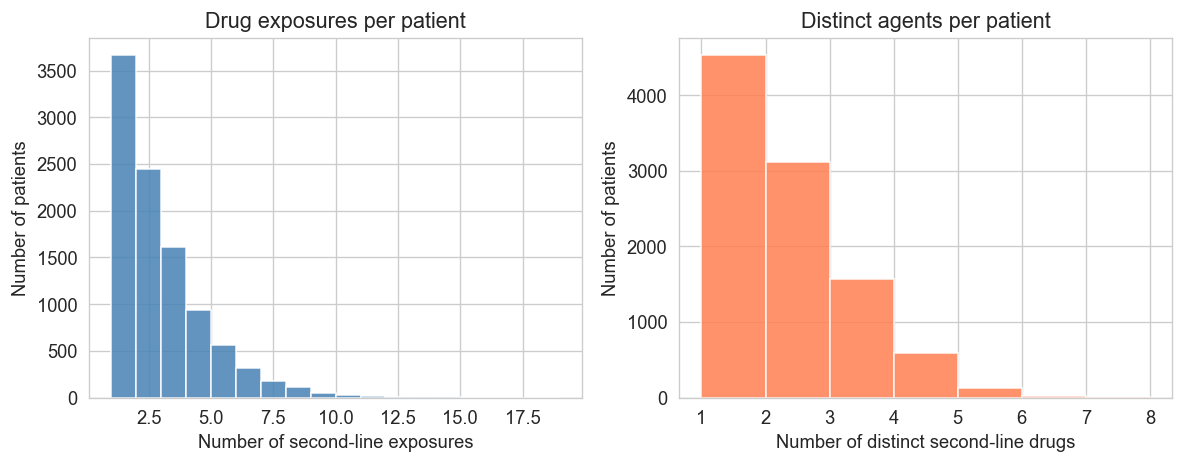

In [65]:
# Sort all exposures by patient and date
pathways = df_raw.sort_values(['person_id', 'second_line_start_date']).copy()

# Build ordered drug sequence per patient
patient_sequences = (
    pathways.groupby('person_id')['second_line_drug_name']
    .apply(list)
    .reset_index()
    .rename(columns={'second_line_drug_name': 'drug_sequence'})
)

# Number of exposures per patient
patient_sequences['n_exposures'] = patient_sequences['drug_sequence'].apply(len)

# Number of distinct drugs per patient
patient_sequences['n_distinct_drugs'] = patient_sequences['drug_sequence'].apply(lambda x: len(set(x)))

print("Exposures per patient:")
print(patient_sequences['n_exposures'].describe().round(1))
print()
print("Distinct second-line drugs per patient:")
print(patient_sequences['n_distinct_drugs'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
patient_sequences['n_exposures'].hist(ax=axes[0], bins=range(1, patient_sequences['n_exposures'].max()+2),
                                       color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of second-line exposures')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Drug exposures per patient')

patient_sequences['n_distinct_drugs'].hist(ax=axes[1], bins=range(1, patient_sequences['n_distinct_drugs'].max()+2),
                                            color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of distinct second-line drugs')
axes[1].set_ylabel('Number of patients')
axes[1].set_title('Distinct agents per patient')

plt.tight_layout()
plt.show()

### 4.2 Most Common Treatment Pathways

The top treatment pathways (ordered sequences of second-line drugs) observed in the cohort. Each pathway is read left to right as the temporal order of drugs received.

In [66]:
# Convert sequences to readable pathway strings
patient_sequences['pathway'] = patient_sequences['drug_sequence'].apply(
    lambda x: ' → '.join(x)
)

# Top pathways
pathway_counts = patient_sequences['pathway'].value_counts().head(15)

print("Top 15 treatment pathways after metformin:")
print("=" * 65)
for i, (pathway, n) in enumerate(pathway_counts.items(), 1):
    pct = n / len(patient_sequences) * 100
    print(f"  {i:>2d}. [{n:>2d} pts, {pct:>4.1f}%]  metformin → {pathway}")

Top 15 treatment pathways after metformin:
   1. [1569 pts, 15.8%]  metformin → glyburide
   2. [1004 pts, 10.1%]  metformin → glipizide
   3. [447 pts,  4.5%]  metformin → glyburide → glyburide
   4. [346 pts,  3.5%]  metformin → rosiglitazone
   5. [296 pts,  3.0%]  metformin → glyburide → glipizide
   6. [280 pts,  2.8%]  metformin → pioglitazone
   7. [270 pts,  2.7%]  metformin → glimepiride
   8. [265 pts,  2.7%]  metformin → glipizide → glyburide
   9. [194 pts,  1.9%]  metformin → glipizide → glipizide
  10. [110 pts,  1.1%]  metformin → sitagliptin
  11. [109 pts,  1.1%]  metformin → rosiglitazone → glyburide
  12. [96 pts,  1.0%]  metformin → glyburide → glyburide → glyburide
  13. [91 pts,  0.9%]  metformin → glyburide → glimepiride
  14. [88 pts,  0.9%]  metformin → rosiglitazone → glipizide
  15. [86 pts,  0.9%]  metformin → glyburide → rosiglitazone


### 4.3 State Transition Analysis

Which drugs do patients transition *between*? This matrix shows the count of observed transitions from one second-line drug to the next in the treatment sequence.

State transition matrix (from → to):
to_drug           glimepiride  glipizide  glyburide  insulin detemir  \
from_drug                                                              
glimepiride               138        379        485                0   
glipizide                 418       1247       1703                4   
glyburide                 578       1769       2398                3   
insulin detemir             0          1          4                0   
insulin glargine            3         18         17                0   
nateglinide                14         31         57                0   
pioglitazone              110        330        447                1   
repaglinide                19         68         94                0   
rosiglitazone             155        468        669                3   
saxagliptin                 1          1          1                0   
sitagliptin                38         93        159                0   
All                      14

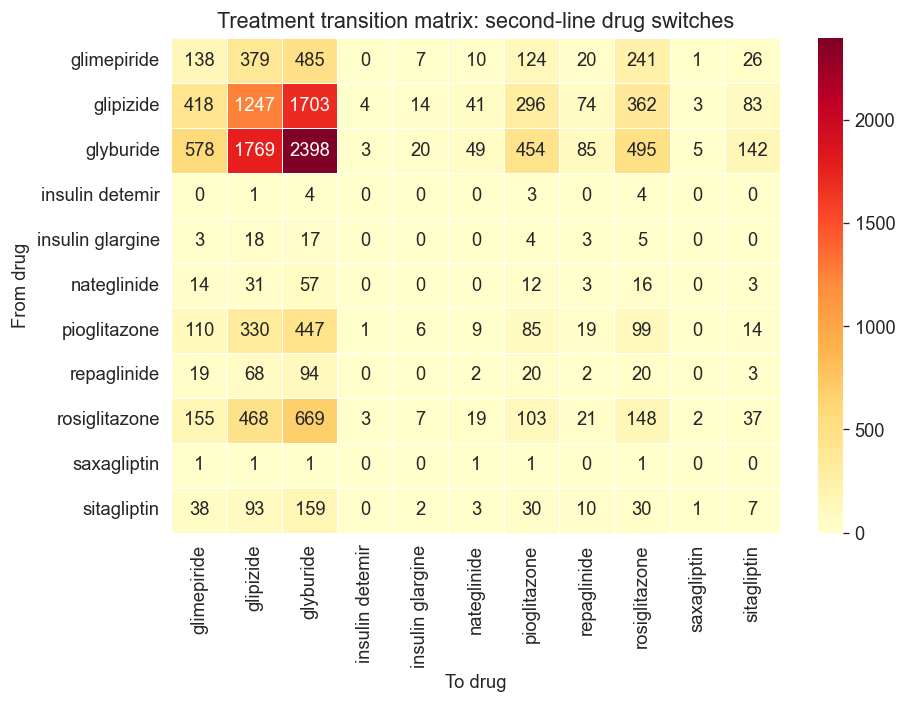


Top 10 most common transitions:
  glyburide → glyburide: 2398
  glyburide → glipizide: 1769
  glipizide → glyburide: 1703
  glipizide → glipizide: 1247
  rosiglitazone → glyburide: 669
  glyburide → glimepiride: 578
  glyburide → rosiglitazone: 495
  glimepiride → glyburide: 485
  rosiglitazone → glipizide: 468
  glyburide → pioglitazone: 454


In [67]:
# Build transition pairs
transitions = []
for _, row in patient_sequences.iterrows():
    seq = row['drug_sequence']
    for i in range(len(seq) - 1):
        transitions.append((seq[i], seq[i+1]))

if len(transitions) > 0:
    trans_df = pd.DataFrame(transitions, columns=['from_drug', 'to_drug'])
    
    # Transition matrix
    trans_matrix = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'], margins=True)
    print("State transition matrix (from → to):")
    print(trans_matrix)
    print()
    
    # Heatmap (without margins)
    trans_clean = pd.crosstab(trans_df['from_drug'], trans_df['to_drug'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(trans_clean, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('To drug')
    ax.set_ylabel('From drug')
    ax.set_title('Treatment transition matrix: second-line drug switches')
    plt.tight_layout()
    plt.show()
    
    # Most common transitions
    print("\nTop 10 most common transitions:")
    top_trans = trans_df.value_counts().head(10)
    for (fr, to), n in top_trans.items():
        print(f"  {fr} → {to}: {n}")
else:
    print("No transitions observed (all patients had only one second-line drug).")

### 4.4 Drug Class Grouping

Grouping individual drugs into pharmacologic classes to reveal higher-level treatment patterns.

First second-line agent by drug class:
----------------------------------------
  Sulfonylurea               n=7570  (76.1%)
  Thiazolidinedione          n=1835  (18.4%)
  DPP-4 inhibitor            n=289  (2.9%)
  Meglitinide                n=218  (2.2%)
  Other                      n= 39  (0.4%)


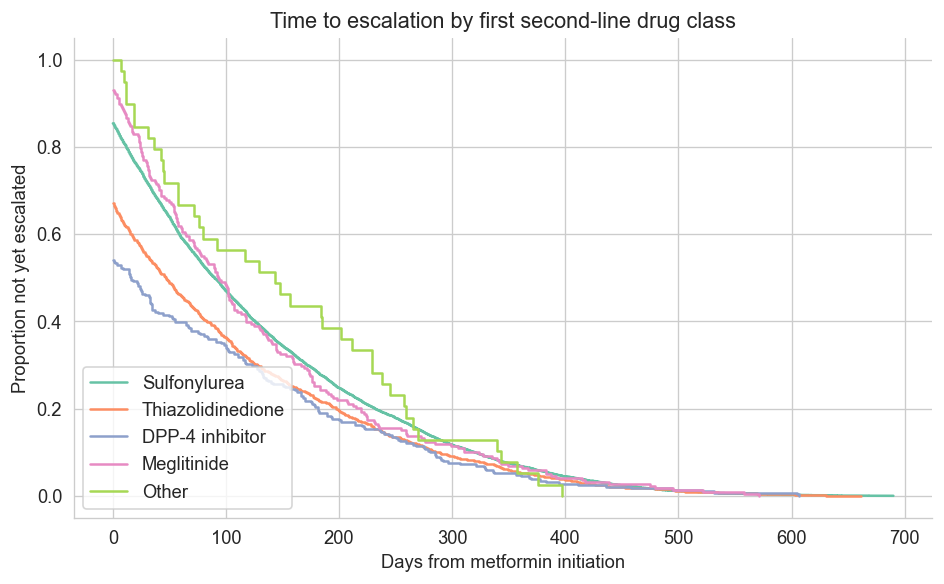

In [68]:
# Drug class mapping
drug_class_map = {
    'glyburide': 'Sulfonylurea',
    'glipizide': 'Sulfonylurea',
    'glimepiride': 'Sulfonylurea',
    'pioglitazone': 'Thiazolidinedione',
    'rosiglitazone': 'Thiazolidinedione',
    'sitagliptin': 'DPP-4 inhibitor',
    'nateglinide': 'Meglitinide',
    'repaglinide': 'Meglitinide',
}

# Map first drug to class
df['first_drug_class'] = df['second_line_drug_name'].map(drug_class_map).fillna('Other')

# Class distribution
class_counts = df['first_drug_class'].value_counts()
print("First second-line agent by drug class:")
print("-" * 40)
for cls, n in class_counts.items():
    print(f"  {cls:<25s}  n={n:>3d}  ({n/len(df)*100:.1f}%)")

# KM by drug class
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()
palette = sns.color_palette("Set2", len(class_counts))

for i, cls in enumerate(class_counts.index):
    mask = df['first_drug_class'] == cls
    if mask.sum() >= 2:
        kmf.fit(df.loc[mask, 'time_to_escalation'],
                event_observed=df.loc[mask, 'event'],
                label=cls)
        kmf.plot_survival_function(ax=ax, ci_show=False, color=palette[i])

ax.set_xlabel('Days from metformin initiation')
ax.set_ylabel('Proportion not yet escalated')
ax.set_title('Time to escalation by first second-line drug class')
ax.legend(loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Study Limitations and Methodological Notes

1. **Selection bias:** This dataset includes only patients who were escalated to a second-line agent. Patients who remained on metformin monotherapy throughout the observation period are excluded. All survival analyses therefore describe the *distribution of escalation timing among those who escalated*, not the overall probability of escalation.

2. **No censoring:** Because all patients in the dataset experienced the event, there are no censored observations. The KM estimator reduces to the empirical CDF, and the Cox model estimates relative differences in escalation speed without the usual censoring adjustments.

3. **Small sample size:** With ~50 unique patients, statistical power is limited. Confidence intervals on hazard ratios are wide, stratified analyses have very small cell sizes, and proportional hazards tests have low power. Results should be interpreted as exploratory.

4. **Unmeasured confounders:** Key clinical variables — HbA1c, BMI, renal function (eGFR), diabetes duration — are not available in this dataset. Prescriber behavior and clinical inertia are also unmeasured. As discussed in the DAG, disease severity is the most important unmeasured confounder.

5. **Observation intensity bias:** Patients with more healthcare encounters have more opportunities for escalation to be documented. Healthcare utilization is not available as a covariate in this extract.

6. **Temporal context:** The cohort start dates cluster around January 2009, which precedes the widespread adoption of SGLT2 inhibitors and GLP-1 receptor agonists. The treatment landscape reflected here is historically specific.

7. **Outcome definition:** The distinction between add-on therapy and drug switching is not explicitly modeled. Both are captured as "second-line initiation."